## Data Importing

In [46]:

# TODO:
# 1. Import the pandas library for data manipulation.
# 2. Load the dataset from the given URL : 
# https://gitlab.crio.do/me_notebook/me_jupyter_airbnbanalysis/-/raw/master/Airbnb_data.csv  into a pandas DataFrame.
# ✅ Step 1: Load and Inspect the Dataset

# 1. Import the pandas library
import pandas as pd

# 2. Load the dataset from the given URL
url = "https://gitlab.crio.do/me_notebook/me_jupyter_airbnbanalysis/-/raw/master/Airbnb_data.csv"
df = pd.read_csv(url)

# 3. Check the number of rows and columns
print("Dataset shape:", df.shape)

# 4. Display concise summary of column types and null counts
print("\nDataset Info:")
df.info()

# 5. Display the first few rows of data
print("\nFirst five rows:")
print(df.head())

# 6. Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())



Dataset shape: (48895, 16)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int

In [47]:
# TODO: Check the number of rows and columns in the DataFrame

# ✅ Step 2: Data Cleaning

# 1. Fill missing values in 'reviews_per_month' with 0
#df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

df['reviews_per_month'].fillna(0, inplace=True)
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# 2. Drop the 'last_review' column
df = df.drop(columns=['last_review'])

# 3. Replace missing values in 'name' and 'host_name' with "unknown"
df['name'] = df['name'].fillna("unknown")
df['host_name'] = df['host_name'].fillna("unknown")

# 4. Check the number of rows and columns again
print("After cleaning, dataset shape:", df.shape)



After cleaning, dataset shape: (48895, 15)


/tmp/ipykernel_52/634488402.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['reviews_per_month'].fillna(0, inplace=True)


## Data Exploration

In [48]:
# TODO: Display concise summary of the DataFrame, including column names, non-null counts, and data types
# ✅ Step 3: Convert Columns to Numeric Types

# Convert 'price' to numeric, coercing invalid values to NaN
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Convert 'availability_365' to numeric, coercing invalid values to NaN
df['availability_365'] = pd.to_numeric(df['availability_365'], errors='coerce')

# Display concise summary (column names, non-null counts, data types)
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48895 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48895 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  reviews_per_month               

In [49]:
# TODO: Display first few rows
# ✅ Step 4: Remove Invalid or Extreme Records

# Drop listings where 'price' is zero or negative
df = df[df['price'] > 0]

# Remove records where 'minimum_nights' is greater than or equal to 365
df = df[df['minimum_nights'] < 365]

# Display the first few rows
print(df.head())


     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews  \
0     Private room    149               1                  9   
1  Entire ho

## Handling Missing Values

In [50]:
# TODO: Check for missing values
import numpy as np

# 1. Calculate Q1 and Q3 for 'number_of_reviews'
Q1 = df['number_of_reviews'].quantile(0.25)
Q3 = df['number_of_reviews'].quantile(0.75)

# 2. Compute IQR and determine lower & upper bounds
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Cap values below or above those bounds
df['number_of_reviews'] = np.where(
    df['number_of_reviews'] < lower_bound, 
    lower_bound,
    np.where(
        df['number_of_reviews'] > upper_bound,
        upper_bound,
        df['number_of_reviews']
    )
)

# ✅ TODO: Check for missing values
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


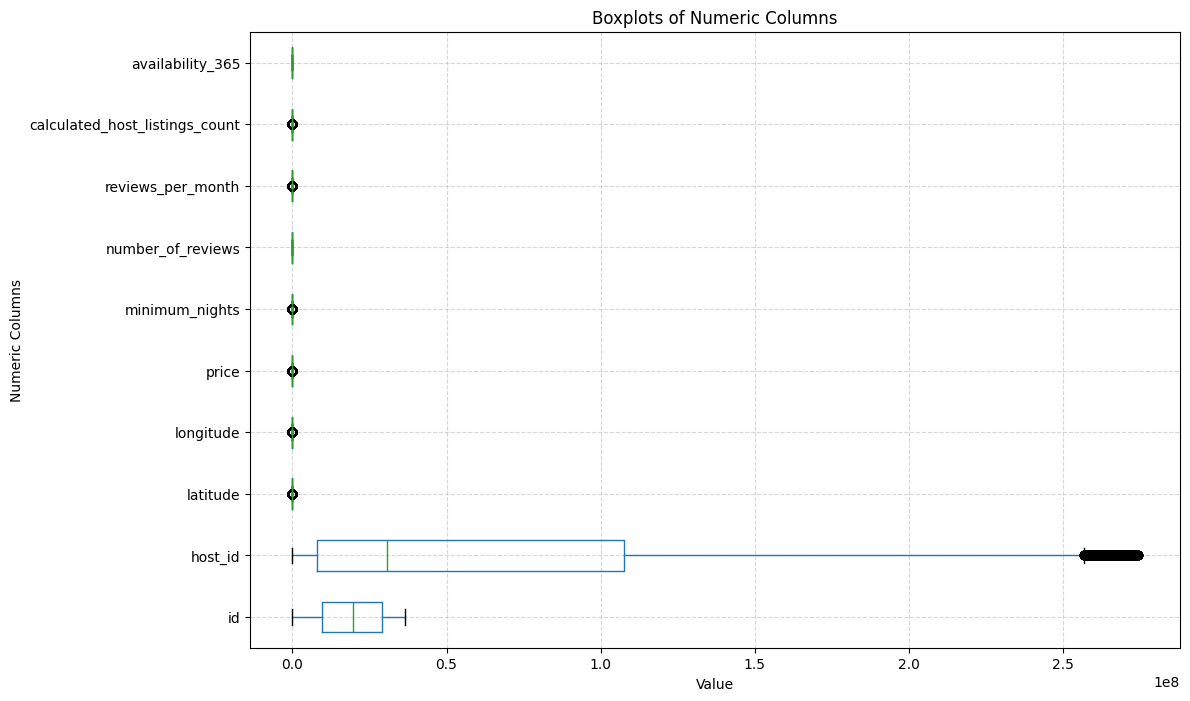

In [51]:
# TODO:
# 1. Fill missing values in 'reviews_per_month' with 0, assuming no reviews for missing entries.
# 2. Drop the 'last_review' column as it's not needed for analysis.
# 3. Replace missing values in the 'name' column with 'unknown'.
# 4. Replace missing values in the 'host_name' column with 'unknown'.

import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Generate horizontal boxplots for each numeric column
plt.figure(figsize=(12, 8))
numeric_df.boxplot(vert=False)  # horizontal orientation
plt.title('Boxplots of Numeric Columns')
plt.xlabel('Value')
plt.ylabel('Numeric Columns')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()



In [52]:
# Re-check missing values
print(df.isnull().sum())


id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


## Handling Outliers

Numeric columns: Index(['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')


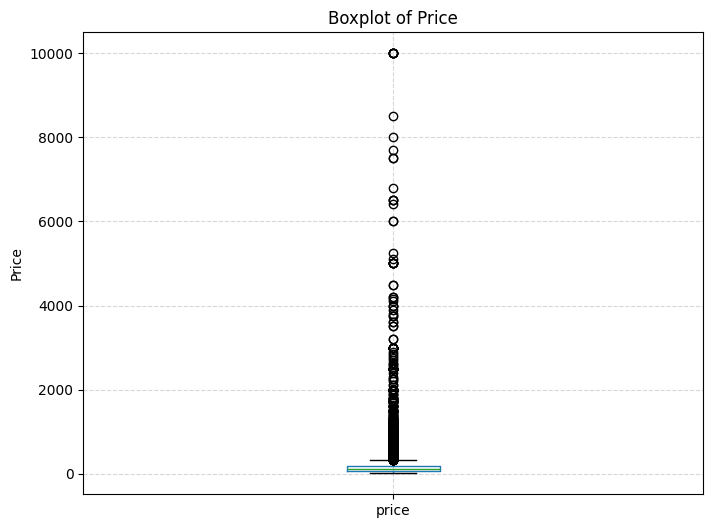

In [53]:
# TODO:
# 1. Import matplotlib for data visualization.
# 2. Select only numeric columns from the DataFrame.
# 3. Plot boxplot for numeric columns price 
import matplotlib.pyplot as plt          # 1. Import matplotlib for data visualization

# 2. Select only numeric columns (just to illustrate; here we’ll focus on ‘price’)
numeric_cols = df.select_dtypes(include=['number']).columns
print("Numeric columns:", numeric_cols)

# 3. Plot boxplot for the ‘price’ column
plt.figure(figsize=(8, 6))
df.boxplot(column=['price'])             # using pandas’ boxplot for a single column
plt.title('Boxplot of Price')
plt.ylabel('Price')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [54]:
# TODO:
# 1. Convert the 'price' column to numeric, coercing any invalid values to NaN.
# 2. Convert the 'availability_365' column to numeric, coercing any invalid values to NaN.

# 1. Convert the 'price' column to numeric, coercing invalid entries to NaN
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# 2. Convert the 'availability_365' column to numeric, coercing invalid entries to NaN
df['availability_365'] = pd.to_numeric(df['availability_365'], errors='coerce')


In [55]:
# TODO:
# 1. Remove listings where 'price' is zero or negative, as they are likely invalid.
# 2. Remove listings with 'minimum_nights' >= 365 to exclude extreme long-term stays.
# 1. Remove listings where 'price' is zero or negative
df = df[df['price'] > 0]

# 2. Remove listings where 'minimum_nights' >= 365
df = df[df['minimum_nights'] < 365]


In [56]:
# TODO:
# 1. Import NumPy for numerical operations.
# 2. Calculate the first (Q1) and third (Q3) quartiles of 'number_of_reviews'.
# 3. Compute the Interquartile Range (IQR) and determine lower and upper bounds for outliers.
# 4. Cap values below the lower bound to the lower threshold.
# 5. Cap values above the upper bound to the upper threshold.


import numpy as np  # 1. Import NumPy for numerical operations

# 2. Calculate Q1 and Q3 for 'number_of_reviews'
Q1 = df['number_of_reviews'].quantile(0.25)
Q3 = df['number_of_reviews'].quantile(0.75)

# 3. Compute the IQR and determine lower & upper bounds
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Cap values below the lower bound to the lower threshold
df['number_of_reviews'] = np.where(
    df['number_of_reviews'] < lower_bound,
    lower_bound,
    df['number_of_reviews']
)

# 5. Cap values above the upper bound to the upper threshold
df['number_of_reviews'] = np.where(
    df['number_of_reviews'] > upper_bound,
    upper_bound,
    df['number_of_reviews']
)


In [57]:
# TODO: Handle outliers for Price column using IQR Method
import numpy as np

# Calculate Q1 & Q3 for the 'price' column
Q1_price = df['price'].quantile(0.25)
Q3_price = df['price'].quantile(0.75)

# Compute IQR
IQR_price = Q3_price - Q1_price

# Determine lower and upper bounds (fences)
lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

# Option A: Cap the outliers rather than drop them
df['price'] = np.where(
    df['price'] < lower_bound_price, 
    lower_bound_price,
    np.where(df['price'] > upper_bound_price, upper_bound_price, df['price'])
)

# Option B: If you prefer removing outlier rows instead of capping
# df = df[(df['price'] >= lower_bound_price) & (df['price'] <= upper_bound_price)]

# (Optional) Check counts or summary after outlier handling
print("After handling outliers in 'price':")
print(df['price'].describe())


After handling outliers in 'price':
count    48841.000000
mean       132.980508
std         83.499442
min         10.000000
25%         69.000000
50%        106.000000
75%        175.000000
max        334.000000
Name: price, dtype: float64


Numeric columns: Index(['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')


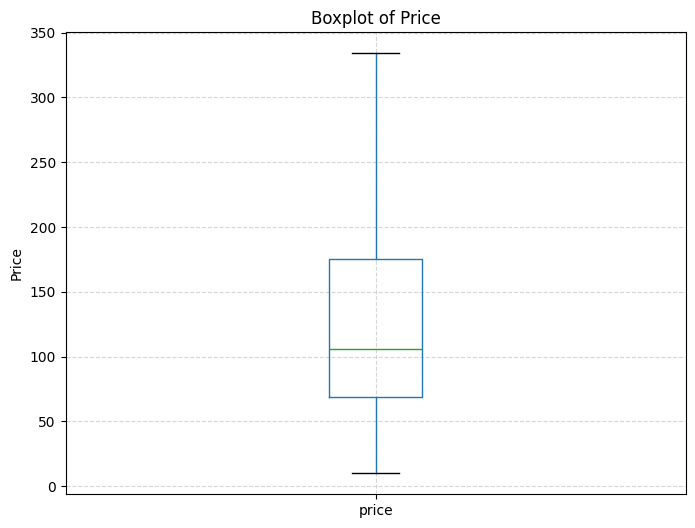

In [58]:
# TODO:
# 1. Import matplotlib for data visualization.
# 2. Select only numeric columns from the DataFrame.
# 3. Plot boxplot for numeric columns price 
import matplotlib.pyplot as plt           # 1. Import matplotlib for data visualization

# 2. Select only numeric columns from the DataFrame
numeric_cols = df.select_dtypes(include=['number']).columns
print("Numeric columns:", numeric_cols)

# 3. Plot boxplot for the 'price' column
plt.figure(figsize=(8, 6))
df.boxplot(column=['price'])
plt.title('Boxplot of Price')
plt.ylabel('Price')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()




Numeric columns: Index(['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')


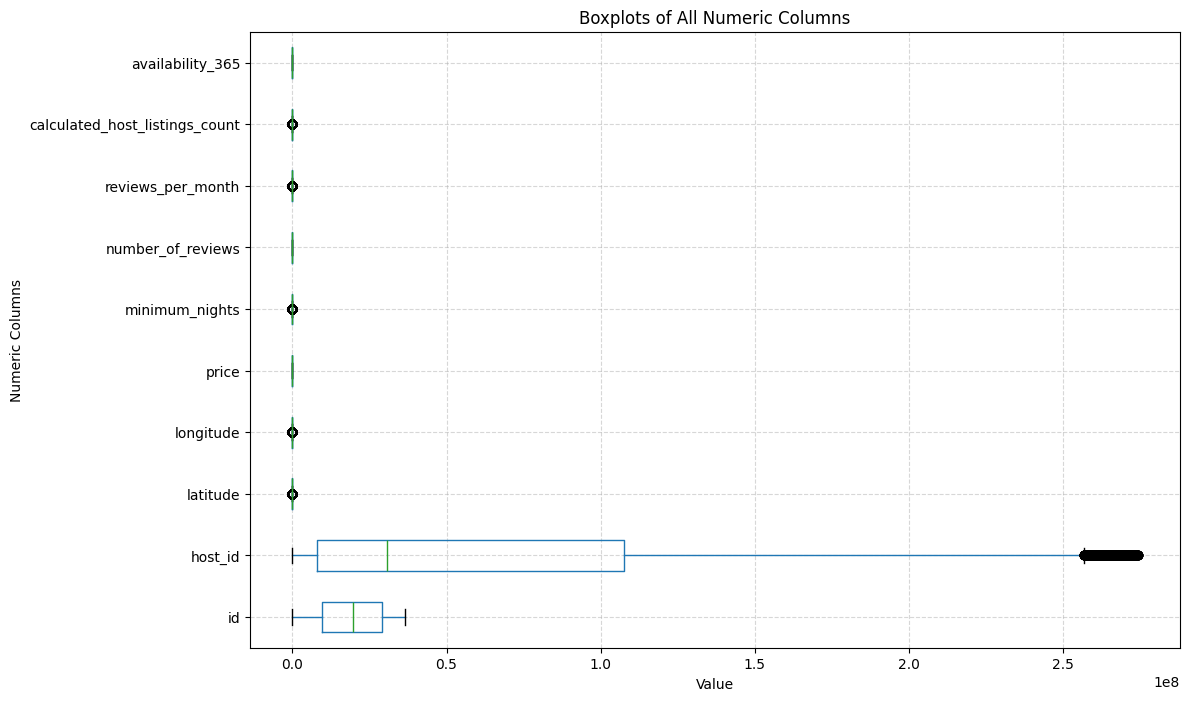

In [59]:
# Follow the same for other columns
import matplotlib.pyplot as plt

# 1. Select only numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns
print("Numeric columns:", numeric_cols)

# 2. Plot boxplots for all numeric columns
plt.figure(figsize=(12, 8))
df[numeric_cols].boxplot(vert=False)   # horizontal orientation for better readability
plt.title('Boxplots of All Numeric Columns')
plt.xlabel('Value')
plt.ylabel('Numeric Columns')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
